# Dataset description
## Opinions of people regarding their earnings
**Source**: DANE

**Download**: [link](https://www.dane.gov.co/index.php/estadisticas-por-tema/salud/calidad-de-vida-ecv/encuesta-nacional-de-calidad-de-vida-ecv-2025)

# Code
## Imports

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

## Load data

In [ ]:
path = "./data/cuadro_21.csv"

cols = [
    "Fecha", "Departamento", "Suficiencia_ingreso", "Porcentaje"
]

df = pd.read_csv(path, encoding="utf-8", usecols=cols)

## Clean data

In [ ]:
df_f = df[df["Departamento"].str.lower().str.startswith("total")]

earnings = df_f["Suficiencia_ingreso"].unique()

opinions = []

for i in earnings:
    tmp = df_f[df_f["Suficiencia_ingreso"].eq(i)]
    tmp.drop(columns=["Departamento", "Suficiencia_ingreso"], inplace=True)
    tmp.set_index("Fecha", inplace=True)
    opinions.append(tmp)

## Plot

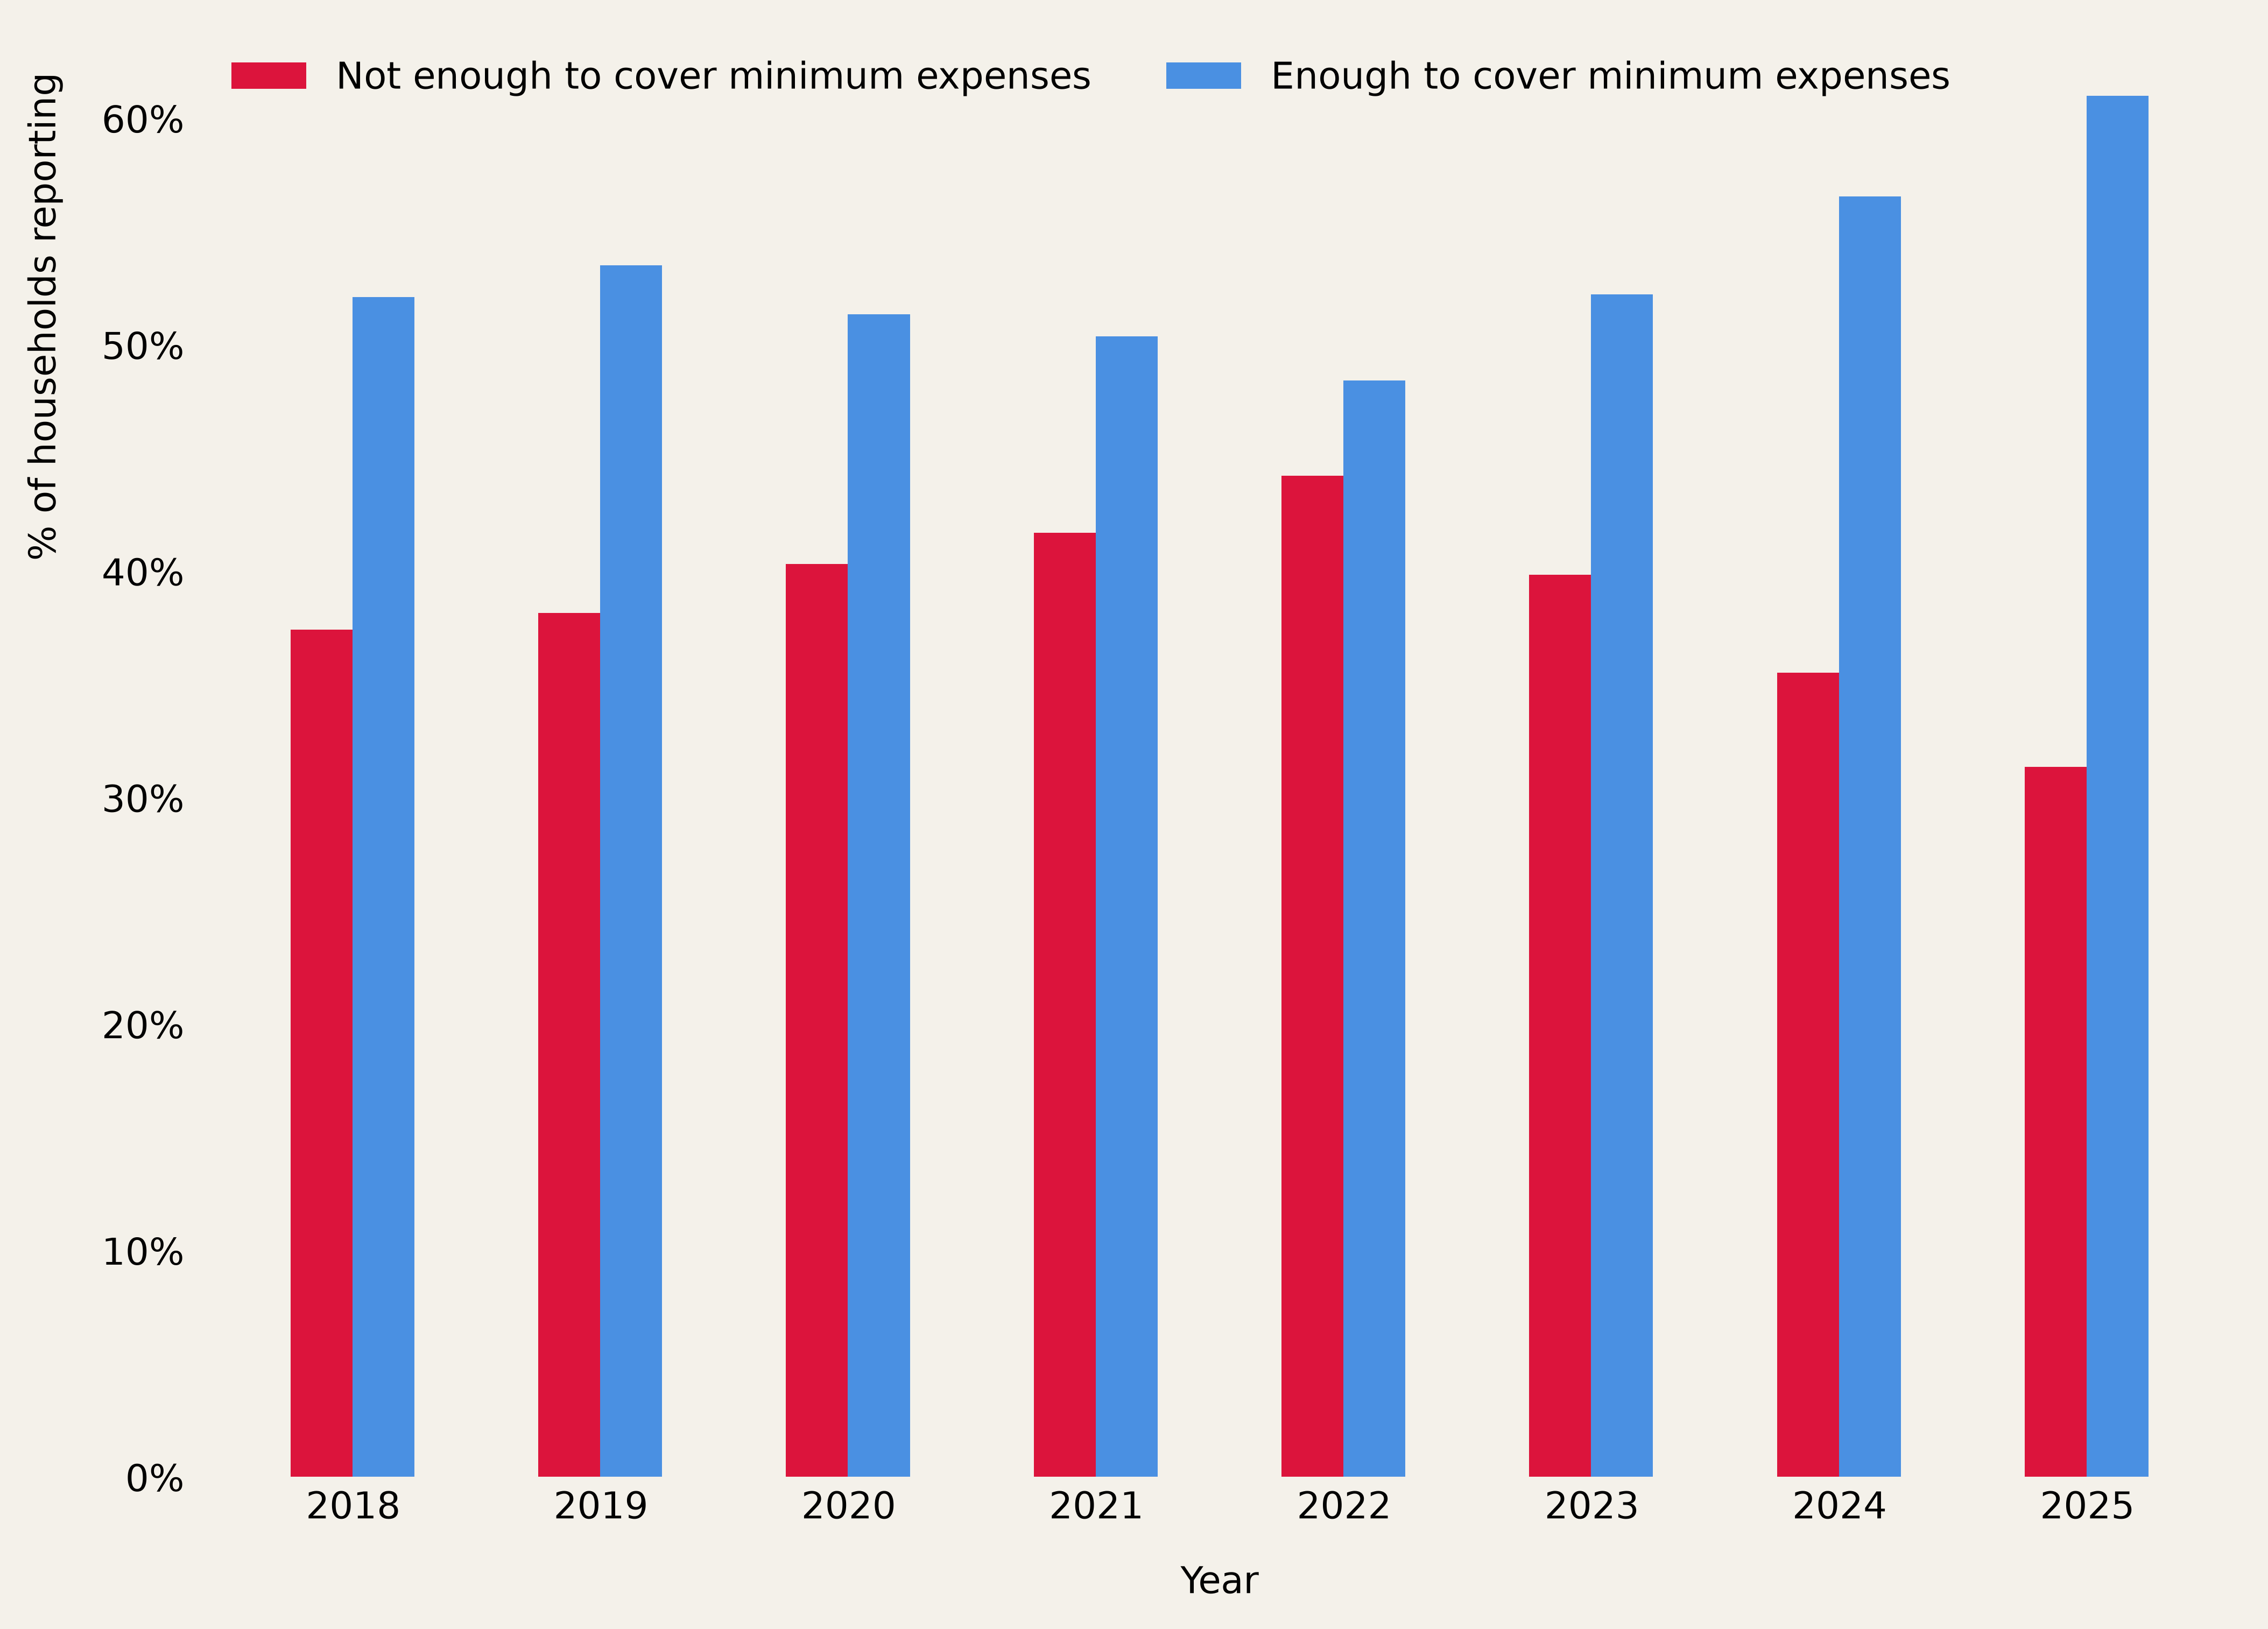

In [75]:
import numpy as np
background = "#F4F1EA"
colors = ["#DC143C", "#4a90e2"]

translation = {
    "No alcanzan para cubrir los gastos mínimos": "Not enough to cover minimum expenses",
    "Alcanzan para cubrir los gastos mínimos": "Enough to cover minimum expenses"
}

earnings_en = earnings.map(translation)

fig, ax = plt.subplots(figsize=(9.8, 7.0), dpi=500)
fig.patch.set_facecolor(background)
ax.patch.set_facecolor(background)

x = np.arange(len(opinions[0]))
width = 0.25

for i, s in enumerate(opinions[0:2]):
    plt.bar(x + i*width, s["Porcentaje"], width, label=earnings_en[i], color=colors[i])

plt.xticks(x + 0.128, opinions[0].index)

for side in ["top", "bottom", "left", "right"]:
    plt.gca().spines[side].set_visible(False)

for axis in ["y", "x"]:
    plt.tick_params(axis=axis, length=0)

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))

plt.ylabel("% of households reporting", labelpad=10, fontsize=10, y=0.8)
plt.xlabel("Year", labelpad=10, fontsize=10)

plt.legend(frameon=False, ncols=2)

plt.show()